In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install tensorflow-addons
!wget -O taipei_sans_tc_beta.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download
import matplotlib
# 新增字體
matplotlib.font_manager.fontManager.addfont('taipei_sans_tc_beta.ttf')
# 將 font-family 設為 Taipei Sans TC Beta
# 設定完後，之後的圖表都可以顯示中文了
matplotlib.rc('font', family='Taipei Sans TC Beta')

Mounted at /content/drive
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 50.3 MB/s eta 0:00:00
--2023-02-07 05:29:52--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 172.253.118.101, 172.253.118.139, 172.253.118.113, ...
Connecting to drive.google.com (drive.google.com)|172.253.118.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://doc-0k-9o-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/9v74ptk3eue0kqhgngpja9im37691aja/1675747725000/02847987870453524430/*/1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_?uuid=ac83a2e2-74c8-4291-ac7b-8354261d5f4b [following]
--2023-02-07 05:29:56--  https://doc-0k-9o-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/9v74ptk3eue0kqhgngpja9im37691aja/1675747725000/02847987870453524430/*/1eGAsTN1HBpJAkeV

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import tensorflow_addons as tfa
import tensorflow as tf
import numpy as np
import os
from random import random
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.layers import Input, Dense, GRU, Bidirectional, LSTM, Embedding
from tensorflow.keras import backend as K
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils import shuffle
from math import sqrt
ROOT = "./"
ROOT = "/content/drive/MyDrive/Colab_2022/blast_forecast/新模型230130 Transformer/"
radam = tfa.optimizers.RectifiedAdam()
ranger = tfa.optimizers.Lookahead(radam, sync_period=6, slow_step_size=0.5)
ranger2 = tfa.optimizers.Lookahead(tfa.optimizers.RectifiedAdam(learning_rate=0.001))
#Show tensorflow version
print(tf.__version__)

2.9.2


In [ ]:
#Custom function 
def weighted_binary_crossentropy(zero_weight, one_weight):
    def weighted_binary_crossentropy(y_true, y_pred):
        b_ce = K.binary_crossentropy(y_true, y_pred)
        #weighted calc
        weight_vector = y_true * zero_weight + (1.0 - y_true) * one_weight
        weighted_b_ce = weight_vector * b_ce
        return K.mean(weighted_b_ce)
    return weighted_binary_crossentropy
def confusion_matrix_calculator(gt_y, prediction):
    TP = ((gt_y + (prediction>0.5))==2).sum()
    TN = ((gt_y + (prediction>0.5))==0).sum()
    FP = ((gt_y - (prediction>0.5))==-1).sum()
    FN = ((gt_y - (prediction>0.5))==1).sum()
    MCC = (TP*TN - FP*FN) / sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))
    return {'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN, 'MCC': MCC, 'ACC': (TP+TN)/(TP+TN+FP+FN)}

In [ ]:
col

In [ ]:
#Load x,y
x_train = np.load(ROOT+'/2_packed_array/x_train.npy', allow_pickle=True)
y_train = np.load(ROOT+'/2_packed_array/y_train.npy', allow_pickle=True)
x_val = np.load(ROOT+'/2_packed_array/x_val.npy', allow_pickle=True)
y_val = np.load(ROOT+'/2_packed_array/y_val.npy', allow_pickle=True)
with open(ROOT+"/2_packed_array/col.txt", 'r', encoding='utf-8-sig') as f:
    col = eval(f.read())
col = col[:]
#normalization
for feature in range(x.shape[2]):
    #x[:, :, feature] = (x[:, :, feature] - np.mean(x[:, :, feature])) / np.std(x[:, :, feature])
    #min-max normalization
    xmin = np.min(x_train[:, :, feature])
    xmax = np.max(x_train[:, :, feature])
    print(col[feature],  xmin, xmax-xmin)
    x_train[:, :, feature] = (x_train[:, :, feature] - xmin) / (xmax - xmin + 0.001)
    x_val[:, :, feature] = (x_val[:, :, feature] - xmin) / (xmax - xmin + 0.001)

temperature_2m_max 10.9 24.300000000000004
temperature_2m_mean 9.9625 21.016666666666666
temperature_2m_min 6.9 21.799999999999997
relativehumidity_2m_max 57.0 43.0
relativehumidity_2m_mean 44.916666666666664 54.00000000000001
relativehumidity_2m_min 34.0 64.0
precipitation_mean 0.0 6.2749999999999995
cloudcover_mean 0.0 100.0
direct_radiation_mean 0.0 282.2083333333333
Wu_mean -45.73243936825596 66.01164576691622
Wv_mean -40.00775993815649 63.11120843486081


<ipython-input-17-f665975b96ce>:8: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(6, 6, feature+1)
<ipython-input-17-f665975b96ce>:8: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(6, 6, feature+1)
<ipython-input-17-f665975b96ce>:8: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always 

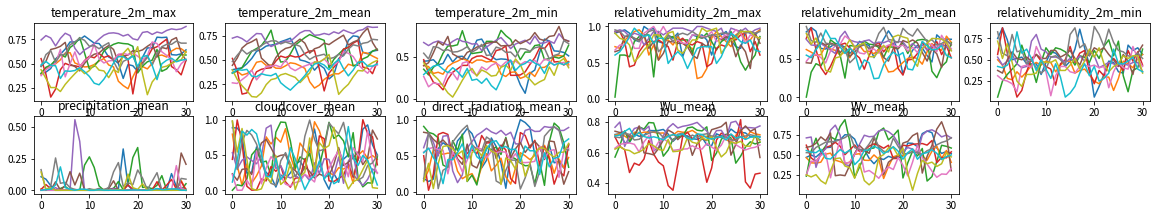

In [ ]:
#Visualize features
plt.figure(figsize=(20, 10))
#Set chinese font 
plt.rcParams['font.sans-serif'] = ['Yu Gothic']
#visualize first 5 samples
for sample in range(10,400,40):
    for feature in range(x_train.shape[2]):
        plt.subplot(6, 6, feature+1)
        plt.plot(x_train[sample, :, feature])
        plt.title(col[feature])

In [105]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Normalization and Attention
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs

    # Feed Forward Part
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    return x + res
def go_train_transformer(train_x, train_y,  val_x, val_y, model_path=ROOT+"/3_model", name_during_training = "5566",neuron_num=256, dropout = 0.2, verbose=0):
    inputs = keras.Input(shape=(train_x.shape[1], train_x.shape[2]))
    x = inputs
    for _ in range(1):
        x = transformer_encoder(x, head_size=8, num_heads=4, ff_dim=4, dropout=dropout)
    x = layers.GlobalAveragePooling1D(data_format="channels_first")(x)
    for dim in [16]:
        x = layers.Dense(dim, activation="relu")(x)
        x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs=inputs, outputs=outputs)
    keras.utils.plot_model(model,model_path+".png")
    model.summary()
    early_stop = tf.keras.callbacks.EarlyStopping(
                                                    monitor='val_loss',
                                                    mode = 'min',
                                                    #monitor='val_accuracy',
                                                    #mode = 'max',
                                                    patience=300
                                                    )
    model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
                                filepath=model_path,
                                save_weights_only=False,
                                monitor='val_loss',
                                mode='min',
                                #monitor='val_accuracy',
                                #mode='max',
                                verbose=verbose,
                                save_best_only=True
                                )
    #Calculate weight
    class_count = np.unique(train_y, return_counts=True)[1]
    total = class_count[0] + class_count[1]
    neg =  class_count[0]
    pos = class_count[1]
    weight_for_0 = (1 / neg) * (total / 2.0)
    weight_for_1 = (1 / pos) * (total / 2.0)
    class_weight = {0: weight_for_0, 1: weight_for_1}
    print(class_weight)
    model.compile(
        #loss=customLoss,
        #loss = weighted_binary_crossentropy(weight_for_0,weight_for_1),
        #loss='mse',
        loss="binary_crossentropy",
        #optimizer=Nadam(),
        #optimizer = ranger,
        #optimizer = tf.keras.optimizers.Adam(),
        optimizer = ranger2,
        metrics=['accuracy'],
        #optimizer=SGD()
        )
    #train_x, train_y = shuffle(train_x, train_y)
    model.fit(train_x,
            train_y,
            epochs=5000,
            batch_size= int(len(train_x)/3),
            validation_data=(val_x, val_y),
            verbose=verbose,
            shuffle=True,
            class_weight=class_weight,
            callbacks=[
            model_checkpoint_callback,
            early_stop,
            ]
            )
    return model





In [106]:
#Selected features
selected_features = [0,6]
ds = (-24,-4)
selected_features_name = [f"*{f}"  if col.index(f) in selected_features else f" {f}" for f in col]
print("\n".join(selected_features_name))

*temperature_2m_max
 temperature_2m_mean
 temperature_2m_min
 relativehumidity_2m_max
 relativehumidity_2m_mean
 relativehumidity_2m_min
*precipitation_mean
 cloudcover_mean
 direct_radiation_mean
 Wu_mean
 Wv_mean


In [107]:
from random import random

In [129]:
x_aug = []
y_aug = []
for x1, y1 in zip(x_train,y_train):
    for shift in range(-1,2):
        if y1 == 0 and shift != 0:
            if random()>0.25:
                continue
        x_aug.append(x1[ds[0]+shift:ds[1]+shift,selected_features])
        y_aug.append(y1)

In [130]:
#shuffle data
X = np.array(x_aug)
Y = np.array(y_aug)
X, Y = shuffle(X, Y)
X_val = x_val[:,ds[0]:ds[1],selected_features]
Y_val = y_val
X_val, Y_val = shuffle(X_val, Y_val)
#Print shape
print("train_x shape: ", X.shape, "train_y shape: ", Y.shape, "val_x shape: ", X_val.shape, "val_y shape: ", Y_val.shape)
#y class count
print("train_y class count: ", np.unique(Y, return_counts=True))

train_x shape:  (1188, 20, 2) train_y shape:  (1188,) val_x shape:  (60, 20, 2) val_y shape:  (60,)
train_y class count:  (array([0, 1], dtype=int32), array([588, 600]))


In [131]:
MODEL_PATH = ROOT+"3_model/"+"230207_Transformer.h5"
name_during_training = "230207"
#tf.keras.backend.clear_session()
#model = go_train(train_x, train_y, val_x, val_y, model_path=MODEL_PATH,neuron_num=36,dropout = 0.05, verbose=1)
model = go_train_transformer(X, Y, X_val, Y_val, model_path=MODEL_PATH,neuron_num=36,dropout = 0.15, verbose=1)
predictor = load_model(MODEL_PATH)
pre = predictor.predict(X_val)
pre = pre.reshape(pre.shape[0])
cf_matrix = confusion_matrix_calculator(Y_val.astype(float), pre)
print(cf_matrix)
print(f"Features: {selected_features}, {selected_features_name}, {ds}")

Model: "model_15"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_16 (InputLayer)          [(None, 20, 2)]      0           []                               
                                                                                                  
 layer_normalization_50 (LayerN  (None, 20, 2)       4           ['input_16[0][0]']               
 ormalization)                                                                                    
                                                                                                  
 multi_head_attention_25 (Multi  (None, 20, 2)       354         ['layer_normalization_50[0][0]', 
 HeadAttention)                                                   'layer_normalization_50[0][0]'] 
                                                                                           

2/2 [==============================] - 0s 4ms/step
{'TP': 25, 'TN': 26, 'FP': 8, 'FN': 1, 'MCC': 0.7233859069307293, 'ACC': 0.85}
Features: [0, 6], ['*temperature_2m_max', ' temperature_2m_mean', ' temperature_2m_min', ' relativehumidity_2m_max', ' relativehumidity_2m_mean', ' relativehumidity_2m_min', '*precipitation_mean', ' cloudcover_mean', ' direct_radiation_mean', ' Wu_mean', ' Wv_mean'], (-24, -4)


In [136]:
print(MODEL_PATH)

/content/drive/MyDrive/Colab_2022/blast_forecast/新模型230130 Transformer/3_model/230207_Transformer.h5


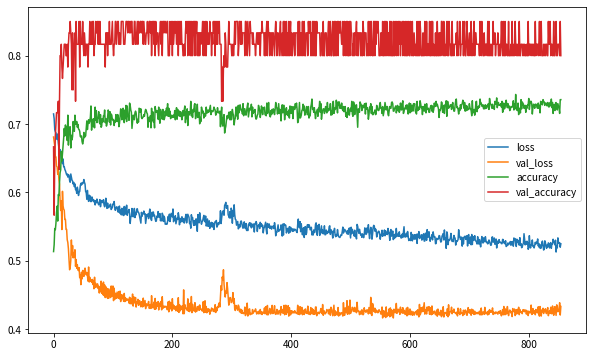

In [134]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(model.history.history['loss'],label = "loss")
ax.plot(model.history.history['val_loss'], label="val_loss")
ax.plot(model.history.history['accuracy'],label = "accuracy")
ax.plot(model.history.history['val_accuracy'], label="val_accuracy")
ax.legend()

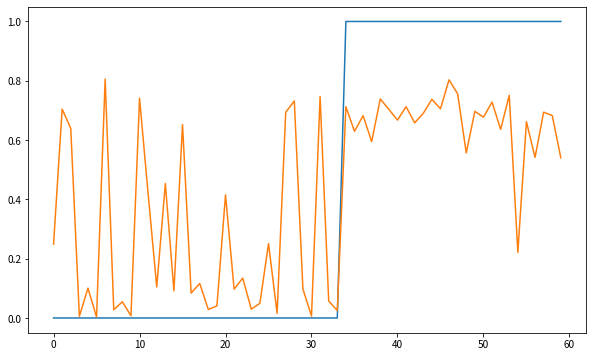

In [135]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(Y_val[np.argsort(Y_val)])
ax.plot(pre[np.argsort(Y_val)])